In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os

# project_path = "/root/25DFT/QHFlow/src/common"
# sys.path.append(project_path)
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
# from common.dft_utils import *
from dft_process.dft_process_utils import *
from common.draw_util import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO     [dft_process_utils.py:32] >> Source path: /root/limlab01/kaistai/25DFT/QHFlow/src

INFO     [dft_process_utils.py:62] >> Root path: /root/limlab01/kaistai/25DFT/QHFlow

In [3]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [4]:
md17_experiment = MD17Experiment(data_index=0)
md17_experiment.set_model_path()

INFO     [setup.py:66] >> Seed: 0

Seed set to 0
Seed set to 0


INFO     [dft_process_utils.py:192] >> [!] conf.dataset.dataset_name: water

In [5]:
dataset = md17_experiment.dataset

print("dataset[0]: ", dataset[0])
print_data_item(dataset[0])

dataset[0]:  AOData(pos=[3, 3], atoms=[3, 1], energy=[1], force=[3, 3], AO_index=[3, 24], hamiltonian=[1, 24, 24], init_ham=[1, 24, 24], overlap=[1, 24, 24], num_atoms=[1], AO_l_index=[12], AO_l_index_len=[1, 1], full_edge_index=[2, 6], mask_row=[3, 14], Q=[24, 24, 60])
data:  AOData(pos=[3, 3], atoms=[3, 1], energy=[1], force=[3, 3], AO_index=[3, 24], hamiltonian=[1, 24, 24], init_ham=[1, 24, 24], overlap=[1, 24, 24], num_atoms=[1], AO_l_index=[12], AO_l_index_len=[1, 1], full_edge_index=[2, 6], mask_row=[3, 14], Q=[24, 24, 60])
 0: atoms          , torch.Size([3, 1])
 1: full_edge_index, torch.Size([2, 6])
 2: pos            , torch.Size([3, 3])
 3: num_atoms      , torch.Size([1])
 4: force          , torch.Size([3, 3])
 5: mask_row       , torch.Size([3, 14])
 6: AO_l_index_len , torch.Size([1, 1])
 7: energy         , torch.Size([1])
 8: hamiltonian    , torch.Size([1, 24, 24])
 9: AO_index       , torch.Size([3, 24])
10: AO_l_index     , torch.Size([12])
11: Q              , torc

In [6]:
pred_list = md17_experiment.pred_list()
print_first_item(pred_list)
gt_list = md17_experiment.gt_list()
print_first_item(gt_list)
print()

len(pred): 3999, water
First item keys: dict_keys(['pred_hamiltonian', 'overlap', 'pos', 'atoms', 'format', 'length_unit'])
len(gt): 3999, water
First item keys: dict_keys(['hamiltonian', 'overlap', 'pos', 'atoms', 'format', 'length_unit', 'init_ham', 'energy', 'force', 'calc_energy', 'calc_forces'])



In [7]:
def matshow(matrix, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], cmap='bwr', colored_norm=False, log=False):
    fig, ax = plt.subplots()
    if matrix.ndim == 3:
        matrix = matrix[0]
    if max_val is None:
        max_val = matrix.abs().max() * max_mul
    cur_matrix = matrix
    if log:
        # Add small constant to avoid log(0)
        eps = 1e-10
        cur_matrix = torch.sign(matrix) * torch.log(torch.abs(matrix) + eps)

    if colored_norm:
        # Use matrix values directly for coloring without normalization
        im = ax.imshow(cur_matrix, cmap=cmap)
    else:
        # Normalize to symmetric range around 0
        im = ax.imshow(cur_matrix, cmap=cmap, vmin=-max_val, vmax=max_val)
        
    if colorbar:
        fig.colorbar(im)
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    spines_name = ['top', 'right', 'bottom', 'left']
    for spine in spines_name:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.5)
    
    if not frame: 
        for spine in spines_name:
            ax.spines[spine].set_visible(False)
    
    cur = 0
    for idx, orb_num in enumerate(drawline):
        color = 'gray'
        ls = '--'
        lw = 0.3
        if orb_num < 0:
            orb_num = -orb_num
            color = 'black'
            ls = '-'
            lw = 0.5
        cur = cur + orb_num
        ax.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
        ax.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=600)
    plt.show()
    
    max_val = matrix.abs().max()
    min_val = matrix.abs().min()
    mean_val = matrix.mean()
    std_val = matrix.std()
    abs_mean_val = matrix.abs().mean()
    abs_std_val = matrix.abs().std()
    statistics = {
        "max_val": max_val,
        "min_val": min_val,
        "abs_mean_val": abs_mean_val,
        "abs_std_val": abs_std_val,
        "mean_val": mean_val,
        "std_val": std_val,
    }
    return statistics

In [8]:
import models.layers_v2 as layers_v2
import e3nn.o3 as o3

In [9]:
expand = layers_v2.PureExpansion(
    o3.Irreps("3x0e + 2x1e + 1x2e"),
    o3.Irreps("3x0e + 2x1e + 1x2e"),
    o3.Irreps("3x0e + 2x1e + 1x2e"),
)

In [10]:
# 1s, 2s, 2p, 3s, 3p, 4s, 3d
index = [
         0, # 1s O
         1, # 2s 
         2, # 3s 
         3,4,5, # 2p
         6,7,8, # 3p
         9,10,11,12,13, # 3d
         14, # 1s
         15, # 2s
         16,17,18, # 2p
         19, # 1s
         20, # 2s
         21,22,23 # 2p    
       ]

drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3]

In [11]:
batch = dataset[0]
batch.ptr = torch.tensor([0, batch.num_nodes])

In [12]:
from common.matrix_transforms import _build_final_matrix, _get_orbital_mask

In [13]:
random_diag_tensor = o3.Irreps("3x0e + 2x1e + 1x2e").randn(
    batch.atoms.shape[0], -1
)
random_non_diag_tensor = o3.Irreps("3x0e + 2x1e + 1x2e").randn(
    batch.full_edge_index.shape[1], -1
)
random_diag_ham = expand(random_diag_tensor)
random_non_diag_ham = expand(random_non_diag_tensor)
random_ham = _build_final_matrix(
 
    batch, random_diag_ham, random_non_diag_ham, _get_orbital_mask()
)
random_ham = torch.stack(random_ham, dim=0) * 1.0

In [14]:
def sym_random(matrix):
    m_dim = matrix.shape[-1]
    i,j = torch.triu_indices(m_dim, m_dim)
    rand_matrix = torch.randn_like(matrix)
    if matrix.ndim == 3:
        rand_matrix[:, i, j] = rand_matrix[:, j, i]
    else:
        rand_matrix[i, j] = rand_matrix[j, i]
    return rand_matrix

In [15]:
GOE0 = sym_random(batch.hamiltonian) * 0.5
Expd0 = (random_ham + random_ham.transpose(-1,-2)) / 2.0
Target0 = batch.hamiltonian

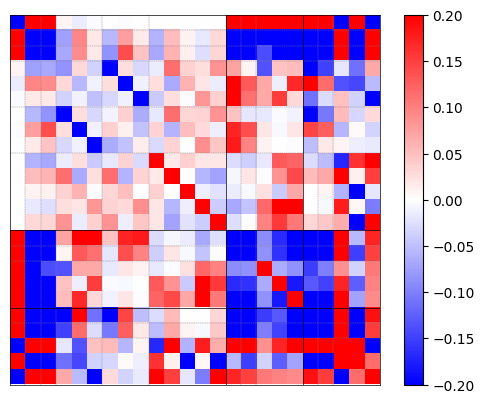

{'max_val': tensor(18.7209),
 'min_val': tensor(0.0001),
 'abs_mean_val': tensor(0.2773),
 'abs_std_val': tensor(0.9648),
 'mean_val': tensor(0.0099),
 'std_val': tensor(1.0038)}

In [16]:
matshow(Target0,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3],max_val=0.2)

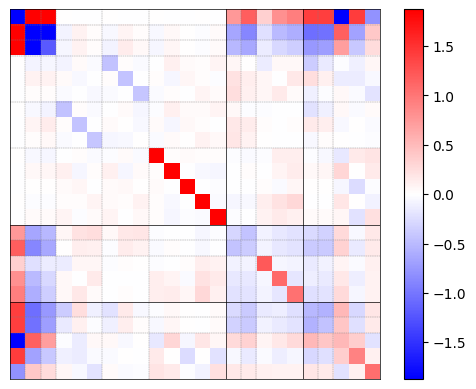

{'max_val': tensor(18.7209),
 'min_val': tensor(0.0001),
 'abs_mean_val': tensor(0.2773),
 'abs_std_val': tensor(0.9648),
 'mean_val': tensor(0.0099),
 'std_val': tensor(1.0038)}

In [17]:
matshow(Target0,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

In [18]:
def matshow(matrix, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], cmap='bwr', colored_norm=False, log=False, show=True):
    fig, ax = plt.subplots()
    if matrix.ndim == 3:
        matrix = matrix[0]
    if max_val is None:
        max_val = matrix.abs().max() * max_mul
    cur_matrix = matrix
    if log:
        # Add small constant to avoid log(0)
        eps = 1e-10
        cur_matrix = torch.sign(matrix) * torch.log(torch.abs(matrix) + eps)

    if colored_norm:
        # Use matrix values directly for coloring without normalization
        im = ax.imshow(cur_matrix, cmap=cmap)
    else:
        # Normalize to symmetric range around 0
        im = ax.imshow(cur_matrix, cmap=cmap, vmin=-max_val, vmax=max_val)
        
    if colorbar:
        fig.colorbar(im)
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    spines_name = ['top', 'right', 'bottom', 'left']
    for spine in spines_name:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.5)
    
    if not frame: 
        for spine in spines_name:
            ax.spines[spine].set_visible(False)
    
    cur = 0
    for idx, orb_num in enumerate(drawline):
        color = 'gray'
        ls = '--'
        lw = 0.3
        if orb_num < 0:
            orb_num = -orb_num
            color = 'black'
            ls = '-'
            lw = 0.5
        cur = cur + orb_num
        ax.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
        ax.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=600)
    if show:
        plt.show()
    
    max_val = matrix.abs().max()
    min_val = matrix.abs().min()
    mean_val = matrix.mean()
    std_val = matrix.std()
    abs_mean_val = matrix.abs().mean()
    abs_std_val = matrix.abs().std()
    statistics = {
        "max_val": max_val,
        "min_val": min_val,
        "abs_mean_val": abs_mean_val,
        "abs_std_val": abs_std_val,
        "mean_val": mean_val,
        "std_val": std_val,
    }
    return statistics, matrix

In [19]:
# import matplotlib.animation as animation
# from tqdm import tqdm

# def create_animation(matrix_sequence, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], cmap='bwr', colored_norm=False, log=False, interval=100):
#     """
#     Create an animation from a sequence of matrices.
    
#     Args:
#         matrix_sequence: List or tensor of matrices to animate
#         max_val: Maximum value for color scaling
#         max_mul: Multiplier for automatic max_val calculation
#         colorbar: Whether to show colorbar
#         frame: Whether to show frame
#         ticks: Whether to show ticks
#         save_name: Path to save animation
#         drawline: List of line positions to draw
#         cmap: Colormap to use
#         colored_norm: Whether to use direct coloring without normalization
#         log: Whether to use log scale
#         interval: Interval between frames in milliseconds
    
#     Returns:
#         animation: Animation object
#         fig: Figure object
#     """
#     fig, ax = plt.subplots()
#     frames = []
    
#     # Set up the initial plot
#     if max_val is None:
#         max_val = torch.abs(matrix_sequence).max() * max_mul
        
#     # Configure axes
#     if not ticks:
#         ax.set_xticks([])
#         ax.set_yticks([])
    
#     spines_name = ['top', 'right', 'bottom', 'left']
#     for spine in spines_name:
#         ax.spines[spine].set_color('black')
#         ax.spines[spine].set_linewidth(0.5)
        
#     if not frame:
#         for spine in spines_name:
#             ax.spines[spine].set_visible(False)
            
#     # Draw reference lines
#     cur = 0
#     for orb_num in drawline:
#         color = 'gray'
#         ls = '--'
#         lw = 0.3
#         if orb_num < 0:
#             orb_num = -orb_num
#             color = 'black'
#             ls = '-'
#             lw = 0.5
#         cur = cur + orb_num
#         ax.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
#         ax.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    
#     # Create frames
#     for matrix in tqdm(matrix_sequence):
#         if matrix.ndim == 3:
#             matrix = matrix[0]
            
#         cur_matrix = matrix
#         if log:
#             eps = 1e-10
#             cur_matrix = torch.sign(matrix) * torch.log(torch.abs(matrix) + eps)
            
#         if colored_norm:
#             im = ax.imshow(cur_matrix, cmap=cmap)
#         else:
#             im = ax.imshow(cur_matrix, cmap=cmap, vmin=-max_val, vmax=max_val)
            
#         frames.append([im])

#     if colorbar:
#         plt.colorbar(im)
        
#     # Create and save animation
#     anim = animation.ArtistAnimation(fig, frames, interval=interval, blit=True)
    
#     if save_name is not None:
#         anim.save(save_name, writer='pillow')
        
#     return anim, fig

In [25]:
import matplotlib.animation as animation
from tqdm import tqdm

def create_animation(matrix_sequence, time_sequence=None, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], cmap='bwr', colored_norm=False, log=False, interval=100):
    """
    Create an animation from a sequence of matrices.
    
    Args:
        matrix_sequence: List or tensor of matrices to animate
        max_val: Maximum value for color scaling
        max_mul: Multiplier for automatic max_val calculation
        colorbar: Whether to show colorbar
        frame: Whether to show frame
        ticks: Whether to show ticks
        save_name: Path to save animation
        drawline: List of line positions to draw
        cmap: Colormap to use
        colored_norm: Whether to use direct coloring without normalization
        log: Whether to use log scale
        interval: Interval between frames in milliseconds
    
    Returns:
        animation: Animation object
        fig: Figure object
    """
    # Create figure with two subplots - matrix above, progress bar below
    fig, (ax_matrix, ax_progress) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [4, 0.25]}, figsize=(4, 4.4))
    frames = []
    
    # Set up the initial plot
    if max_val is None:
        max_val = torch.abs(matrix_sequence).max() * max_mul
        
    # Configure matrix axes
    if not ticks:
        ax_matrix.set_xticks([])
        ax_matrix.set_yticks([])
    
    spines_name = ['top', 'right', 'bottom', 'left']
    for spine in spines_name:
        ax_matrix.spines[spine].set_color('black')
        ax_matrix.spines[spine].set_linewidth(0.5)
        
    if not frame:
        for spine in spines_name:
            ax_matrix.spines[spine].set_visible(False)
            
    # Draw reference lines
    cur = 0
    for orb_num in drawline:
        color = 'gray'
        ls = '--'
        lw = 0.3
        if orb_num < 0:
            orb_num = -orb_num
            color = 'black'
            ls = '-'
            lw = 0.5
        cur = cur + orb_num
        ax_matrix.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
        ax_matrix.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    
    # Configure progress bar axes
    ax_progress.set_xlim(0, len(matrix_sequence)-1)
    ax_progress.set_ylim(0, 1)
    ax_progress.set_xticks([])
    ax_progress.set_yticks([])
    ax_progress.set_xlabel('Time Progress')
    
    if time_sequence is None:
        time_sequence = torch.linspace(0, 1, len(matrix_sequence))
    # Create frames
    for i, matrix in tqdm(zip(time_sequence, matrix_sequence)):
        if matrix.ndim == 3:
            matrix = matrix[0]
            
        cur_matrix = matrix
        if log:
            eps = 1e-10
            cur_matrix = torch.sign(matrix) * torch.log(torch.abs(matrix) + eps)
            
        if colored_norm:
            im = ax_matrix.imshow(cur_matrix, cmap=cmap)
        else:
            im = ax_matrix.imshow(cur_matrix, cmap=cmap, vmin=-max_val, vmax=max_val)
            
        # Update progress bar
        progress = ax_progress.fill_between([0, i], [1, 1], color='black', alpha=0.5)
        time_point = ax_progress.axvline(x=i, color='red', linewidth=2)
            
        frames.append([im, progress, time_point])

    if colorbar:
        plt.colorbar(im, ax=ax_matrix)
    
    plt.tight_layout()
        
    # Create and save animation
    anim = animation.ArtistAnimation(fig, frames, interval=interval, blit=True)
    
    if save_name is not None:
        anim.save(save_name, writer='pillow')
        
    return anim, fig

60it [00:00, 285.68it/s]
INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


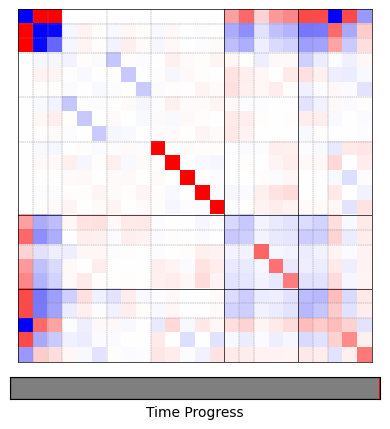

In [26]:
matrix_list = []
time_list = []
num_frames = 60
first_stage = num_frames
# first_stage = int(num_frames * 0.7)
# second_stage = num_frames - first_stage

for i in range(first_stage):
    # cur_t = (1 - np.exp(-5 * i / (num_frames-1))) / (1 - np.exp(-5))
    cur_t = i / (first_stage-1)    
    matrix_list.append(Target0 * cur_t + Expd0 * (1-cur_t))
    time_list.append(cur_t * (num_frames-1))

# for i in range(second_stage):
#     # stationary
#     matrix_list.append(Target0)
#     time_list.append(1 * (num_frames-1))

matrix_list = torch.stack(matrix_list, dim=0)

anim, fig = create_animation(
    matrix_list,
    time_sequence=time_list,
    max_val=2,
    colorbar=False,
    frame=True,
    save_name="animation_temp4.gif",
    drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3],
    cmap='bwr',
    interval=0.5
)


In [22]:
time_list

[0.0,
 1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 18.0,
 19.0,
 20.0,
 21.0,
 22.0,
 23.0,
 24.0,
 25.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0,
 31.000000000000004,
 32.0,
 33.0,
 34.0,
 35.0,
 36.0,
 37.0,
 38.0,
 39.0,
 40.0,
 41.0,
 42.0,
 43.0,
 44.0,
 45.0,
 46.0,
 47.0,
 48.0,
 49.0,
 50.0,
 51.0,
 52.0,
 53.0,
 54.0,
 55.0,
 56.0,
 57.0,
 58.0,
 59.0]

In [23]:
# matrix_list = []
# num_frames = 120
# for i in range(num_frames):
#     cur_t = i / (num_frames-1)
#     matrix_list.append(Target0 * cur_t + Expd0 * (1-cur_t))

# anim, fig = create_animation(
#     matrix_list,
#     max_val=0.2,
#     colorbar=True,
#     frame=True,
#     save_name="animation.gif",
#     drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3],
#     cmap='bwr',
#     interval=0.33
# )




In [24]:
# matrix_list = []
# num_frames = 120
# for i in range(num_frames):
#     cur_t = i / (num_frames-1)
#     matrix_list.append(Target0 * cur_t + Expd0 * (1-cur_t))

# anim, fig = create_animation(
#     matrix_list,
#     max_val=0.2,
#     colorbar=True,
#     frame=True,
#     save_name="animation2.gif",
#     drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3],
#     cmap='bwr',
#     interval=0.33
# )


